In [ ]:
import pypsa
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns
import re

### Paths

In [67]:
trade_model = "../../results/cost_year~2030/transport_cost~steel_r_iron_r/demand~1/product~steel/network.nc"

### Read trade model

In [68]:
n = pypsa.Network(trade_model)

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads


### Overview

In [78]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator iron_ore               2.767431e+09                 0.0   
Link      shipping_iron_ore      1.870700e+09                 0.0   
          shipping_steel         1.268162e+09                 0.0   
          steel                  2.767431e+09                 0.0   
Load      -                      0.000000e+00                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator iron_ore           2.767431e+09  0.000000e+00    2.767431e+09   
Link      shipping_iron_ore  0.000000e+00  1.870700e+09   -1.870700e+09   
          shipping_steel     0.000000e+00  1.268162e+09   -1.268162e+09   
          steel              0.000000e+00  2.767431e+09   -2.767431e+09   
Load      -                  0.000000e+00  1.729761e+09   -1.729761e+09   

                             Transmission  Capacity Factor  Curtailment  \
Generator iron_ore           0.000000e+00              1.0          0.0   
Link      shipping_iron_ore  1.870700e+09              1.0          0.0   
          shipping_steel     1.268162e+09              1.0          0.0   
          steel              0.000000e+00              1.0          0.0   
Load      -                  0.000000e+00              NaN          0.0   

                             Capital Expenditure  Operational Expenditure  \
Generator iron_ore                  2.767431e+06             2.703780e+11   
Link      shipping_iron_ore         1.870700e+06             3.342626e+10   
          shipping_steel            1.268162e+06             3.894365e+10   
          steel                     2.767431e+06             8.215322e+11   
Load      -                         0.000000e+00             0.000000e+00   

                                  Revenue  Market Value  
Generator iron_ore           3.044146e+11    109.998982  
Link      shipping_iron_ore -2.040112e+11           NaN  
          shipping_steel    -8.422650e+11           NaN  
          steel             -3.378427e+11           NaN  
Load      -                 -1.223561e+12           NaN

### Steel supply costs

In [82]:
n.links[n.links.carrier == 'steel'].marginal_cost

Link
steel supply Europe_1      285.587361
steel supply Europe_2      288.417346
steel supply Europe_3      292.182561
steel supply Europe_4      294.298177
steel supply Europe_5      295.592839
                              ...    
steel supply Oceania_35    308.007087
steel supply Oceania_40    311.937668
steel supply Oceania_50    313.695105
steel supply Oceania_55    320.329827
steel supply Oceania_60    316.335997
Name: marginal_cost, Length: 200, dtype: float64

### Iron ore and steel price

In [72]:
# Iron ore price analysis
iron_ore_price = n.buses_t.marginal_price.loc[:, n.buses[n.buses.carrier == "iron_ore"].index]

# Steel price analysis
steel_price = n.buses_t.marginal_price.loc[:, n.buses[n.buses.carrier == "steel"].index]

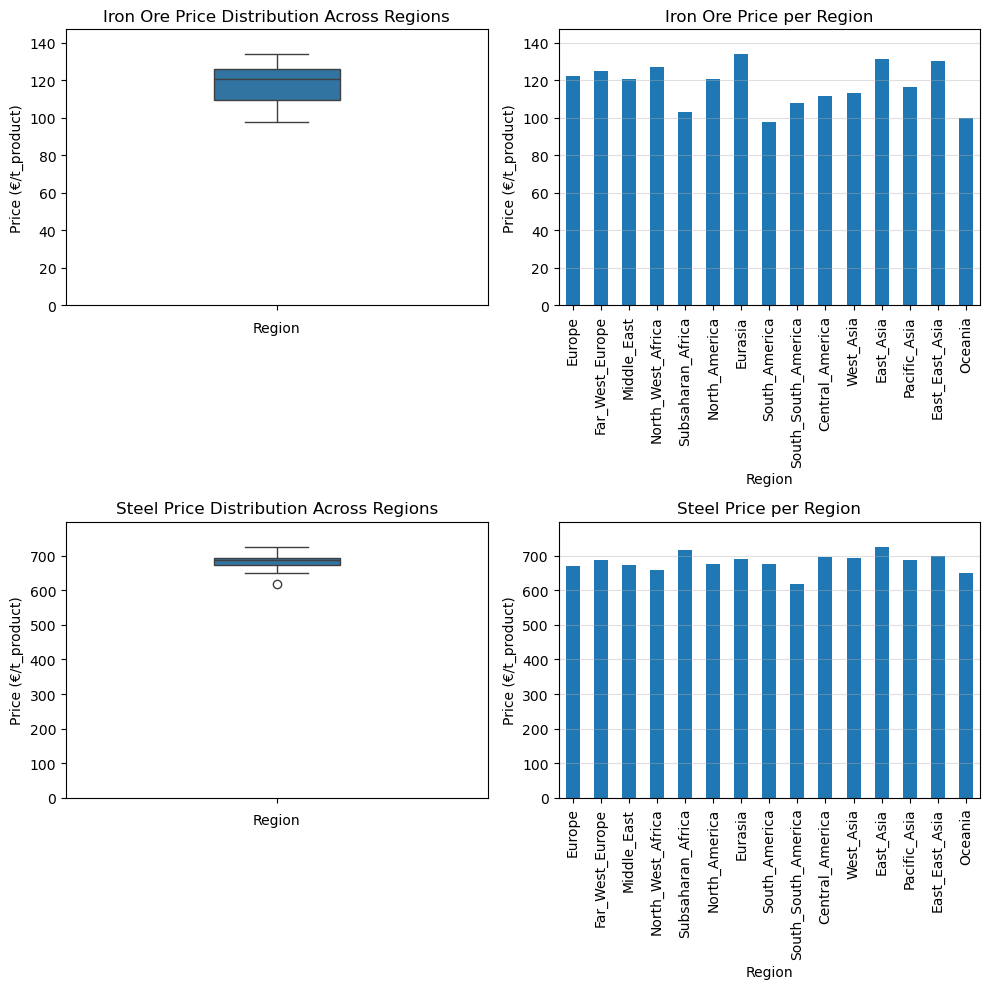

In [77]:
# Helper to clean region names (remove _ore)
def clean_region_names(index):
    return [re.sub(r'_ore$', '', str(i)) for i in index]

# Prepare data for both carriers
data = {
    'iron_ore': iron_ore_price,
    'steel': steel_price
}
titles = {
    'iron_ore': 'Iron Ore',
    'steel': 'Steel'
}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (carrier, price_df) in enumerate(data.items()):
    # Clean region names
    price_df = price_df.copy()
    price_df.columns = clean_region_names(price_df.columns)
    price_T = price_df.T
    price_T.columns = ['Price']
    price_T.index = clean_region_names(price_T.index)

    # Boxplot (narrower)
    sns.boxplot(data=price_df.melt(var_name='Region', value_name=""), ax=axes[i,0], width=0.3)
    axes[i,0].set_title(f'{titles[carrier]} Price Distribution Across Regions')
    axes[i,0].set_ylabel('Price (€/t_product)')
    axes[i,0].set_xlabel('Region')
    axes[i,0].set_ylim(0, price_df.max().max() * 1.1)

    # Bar plot
    price_T.plot(kind='bar', ax=axes[i,1], legend=False, width=0.5)
    axes[i,1].set_title(f'{titles[carrier]} Price per Region')
    axes[i,1].set_ylabel('Price (€/t_product)')
    axes[i,1].set_xlabel('Region')
    axes[i,1].set_xticklabels(price_T.index, rotation=90)
    axes[i,1].set_ylim(0, price_df.max().max() * 1.1)
    axes[i,1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()